# 05 - Uncertainty quantification

Three drop-in estimators in `maldideepkit.uncertainty` wrap a fitted classifier and report per-sample uncertainty alongside the usual predictions:

1. **Monte Carlo Dropout** - stochastic forward passes with dropout layers active. Decomposes total uncertainty into *epistemic* (model disagreement) and *aleatoric* (data noise) components (Gal & Ghahramani, 2016; Kendall & Gal, 2017).
2. **Laplace approximation** - last-layer or full-network Gaussian posterior over the weights, via [`laplace-torch`](https://github.com/aleximmer/Laplace). Requires the optional `uncertainty` extra: `pip install "maldideepkit[uncertainty]"`.
3. **Split conformal prediction** - distribution-free prediction *sets* with a coverage guarantee. Pure NumPy, no extra deps.

All three return a common `UncertaintyResult` dataclass, so call sites stay the same when you swap methods.

Uses the **MALDI-Kleb-AI** dataset cached by `notebooks/_demo.py` (see notebook 01).

## 1. Load the demo dataset

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make notebooks/_demo.py importable
from notebooks._demo import binary_labels, load_maldi_kleb_ai

demo = load_maldi_kleb_ai(antibiotic='Amikacin', verbose=True)
X, y = binary_labels(demo)  # y == 1 for resistant
print(f'X: {X.shape} | prevalence(R): {y.mean():.2%}')

Processing spectra:   0%|          | 0/743 [00:00<?, ?spectrum/s]

X: (741, 6000) | prevalence(R): 49.80%


## 2. Train / calibration / test split

We carve the data into three disjoint pieces:

- **train** - fits the base `MaldiMLPClassifier`.
- **calibration** - held out for `LaplaceEstimator.calibrate()` and `ConformalPredictor.calibrate()`. MC Dropout needs no calibration set.
- **test** - never seen during training or calibration; the uncertainty estimates we evaluate below all come from this split.

In [2]:
from sklearn.model_selection import train_test_split

X_tr, X_rest, y_tr, y_rest = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=0,
)
X_cal, X_te, y_cal, y_te = train_test_split(
    X_rest, y_rest, test_size=0.50, stratify=y_rest, random_state=0,
)
print(f'train: {X_tr.shape[0]} | cal: {X_cal.shape[0]} | test: {X_te.shape[0]}')

train: 444 | cal: 148 | test: 149


## 3. Fit the base classifier

`MaldiMLPClassifier` ships with dropout layers on by default, so the same fitted model serves all three uncertainty estimators below. We add `calibrate_temperature=True` to keep the softmax probabilities well-scaled before any post-hoc calibration kicks in.

In [3]:
from maldideepkit import MaldiMLPClassifier

clf = MaldiMLPClassifier(
    epochs=40,
    batch_size=32,
    calibrate_temperature=True,
    random_state=0,
).fit(X_tr, y_tr)

print(f'test accuracy: {clf.score(X_te, y_te):.3f}')
print(f'fitted temperature: {clf.temperature_:.3f}')

test accuracy: 0.779
fitted temperature: 1.293


## 4. Monte Carlo Dropout

Run `n_samples=50` stochastic forward passes through `clf.model_` with dropout layers kept in training mode. The variance of the resulting softmax distribution is interpreted as *epistemic* uncertainty (model disagreement); the mean of the per-pass entropies is interpreted as *aleatoric* uncertainty (data noise).

No calibration step is needed - MC Dropout reuses the dropout stochasticity baked into the fitted model.

In [4]:
import numpy as np
from maldideepkit.uncertainty import MCDropoutEstimator

mc = MCDropoutEstimator(clf, n_samples=50)
mc_result = mc.predict_with_uncertainty(X_te)

print(f'method:        {mc_result.method}')
print(f'predictions:   {mc_result.predictions.shape}')
print(f'proba_mean:    {mc_result.proba_mean.shape}')
print(f'total H:       mean={mc_result.uncertainty.mean():.3f}  '
      f'p10={np.quantile(mc_result.uncertainty, 0.1):.3f}  '
      f'p90={np.quantile(mc_result.uncertainty, 0.9):.3f}')
print(f'epistemic:     mean={mc_result.epistemic.mean():.3f}')
print(f'aleatoric:     mean={mc_result.aleatoric.mean():.3f}')

method:        mc_dropout
predictions:   (149,)
proba_mean:    (149, 2)
total H:       mean=0.411  p10=0.021  p90=0.960
epistemic:     mean=0.070
aleatoric:     mean=0.340


Plot the epistemic / aleatoric decomposition. A spectrum with high *epistemic* uncertainty is one the model has not seen enough similar examples of - a candidate for active labelling. High *aleatoric* uncertainty signals genuine label ambiguity that more data will not resolve.

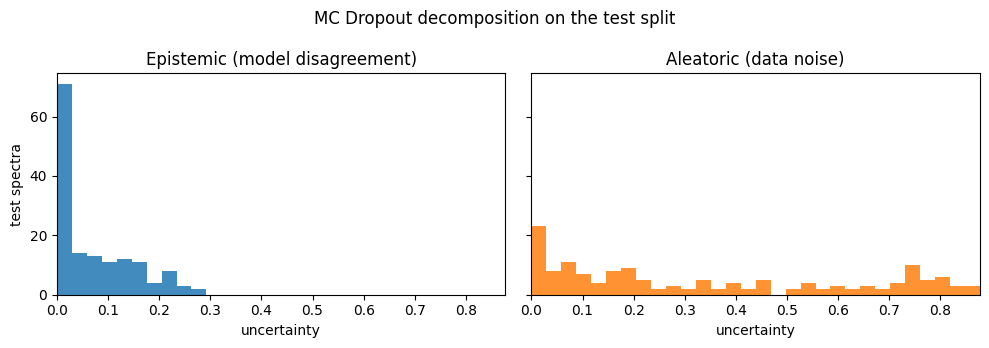

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x_max = float(np.maximum(mc_result.epistemic.max(), mc_result.aleatoric.max()))
bins = np.linspace(0.0, x_max, 31)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True, sharey=True)
axes[0].hist(mc_result.epistemic, bins=bins, color='C0', alpha=0.85)
axes[0].set_title('Epistemic (model disagreement)')
axes[0].set_xlabel('uncertainty')
axes[0].set_ylabel('test spectra')
axes[1].hist(mc_result.aleatoric, bins=bins, color='C1', alpha=0.85)
axes[1].set_title('Aleatoric (data noise)')
axes[1].set_xlabel('uncertainty')
axes[0].set_xlim(0.0, x_max)
fig.suptitle('MC Dropout decomposition on the test split')
fig.tight_layout()
plt.show()

## 5. Split conformal prediction

`ConformalPredictor` learns a single quantile on the calibration split, then returns a *prediction set* per test spectrum that contains the true class with marginal probability $\geq 1 - \alpha$. With `alpha=0.1` we target 90 % coverage.

Per-sample uncertainty is the prediction set size normalised by `n_classes`: `1 / n_classes` for a confident singleton, `1.0` when every class is included.

In [6]:
from maldideepkit.uncertainty import ConformalPredictor

cp = ConformalPredictor(clf, alpha=0.10).calibrate(X_cal, y_cal)
cp_result = cp.predict_with_uncertainty(X_te)

sets = cp_result.metadata['prediction_sets']           # (n_test, n_classes) bool
set_sizes = cp_result.metadata['set_sizes']            # (n_test,) int
covered = sets[np.arange(len(y_te)), np.asarray(y_te)]

print(f'target coverage:    {1 - cp.alpha:.2f}')
print(f'empirical coverage: {covered.mean():.3f}')
print(f'mean set size:      {set_sizes.mean():.2f}  '
      f'(singleton fraction: {(set_sizes == 1).mean():.2f})')
print(f'calibration n:      {cp_result.metadata["n_calibration"]}')

target coverage:    0.90
empirical coverage: 0.960
mean set size:      1.62  (singleton fraction: 0.38)
calibration n:      148


Conformal prediction *sets* are most useful when the model is uncertain: a singleton means the model is confident, a full set means "could be either". Inspect a few examples on the test split.

In [7]:
import pandas as pd

classes = np.asarray(clf.classes_)
rng = np.random.default_rng(0)
rows = []
for i in rng.choice(len(y_te), size=8, replace=False):
    members = classes[sets[i]].tolist()
    rows.append({
        'true_y':         int(np.asarray(y_te)[i]),
        'argmax_y':       int(cp_result.predictions[i]),
        'p(argmax)':      float(cp_result.proba_mean[i].max().round(3)),
        'set':            members,
        'set_size':       int(set_sizes[i]),
        'covered':        bool(covered[i]),
    })
pd.DataFrame(rows)

,true_y,argmax_y,p(argmax),set,set_size,covered
0,1,1,0.768,"[0, 1]",2,True
1,1,1,0.997,[1],1,True
2,1,0,0.532,"[0, 1]",2,True
3,1,1,1.000,[1],1,True
4,0,0,0.931,"[0, 1]",2,True
5,0,0,0.977,[0],1,True
6,1,1,0.731,"[0, 1]",2,True
7,0,0,0.759,"[0, 1]",2,True


## 6. Laplace approximation

`LaplaceEstimator` fits a Gaussian approximation of the posterior over the weights and turns the predictive variance into a per-sample uncertainty estimate. We use the cheap `subset_of_weights="last_layer"` + `hessian_structure="diag"` defaults; bump them up to `"all"` / `"kron"` for slower but more expressive posteriors.

Requires the optional `uncertainty` extra:

```bash
pip install "maldideepkit[uncertainty]"
```

In [8]:
try:
    from maldideepkit.uncertainty import LaplaceEstimator
    la = LaplaceEstimator(
        clf,
        subset_of_weights='last_layer',
        hessian_structure='diag',
    ).calibrate(X_cal, y_cal)
    la_result = la.predict_with_uncertainty(X_te)
    print(f'method:    {la_result.method}')
    print(f'total H:   mean={la_result.uncertainty.mean():.3f}')
    print(f'epistemic: mean={la_result.epistemic.mean():.3f}')
    print(f'aleatoric: mean={la_result.aleatoric.mean():.3f}')
    print(f'predictive variance (per-sample mean): '
          f'{la_result.metadata["predictive_variance"].mean():.4f}')
    have_laplace = True
except ImportError as exc:
    print(f'LaplaceEstimator unavailable - install with `pip install "maldideepkit[uncertainty]"`.')
    print(f'  ({exc})')
    have_laplace = False

method:    laplace
total H:   mean=0.442
epistemic: mean=0.022
aleatoric: mean=0.419
predictive variance (per-sample mean): 0.0224


## 7. Selective prediction with the uncertainty signal

A practical use of any of these scalar uncertainties is **selective prediction**: refuse to answer when the model is unsure. Sweep a coverage threshold ("only answer on the most-confident X % of the test set") and watch accuracy improve as we abstain on the noisy tail.

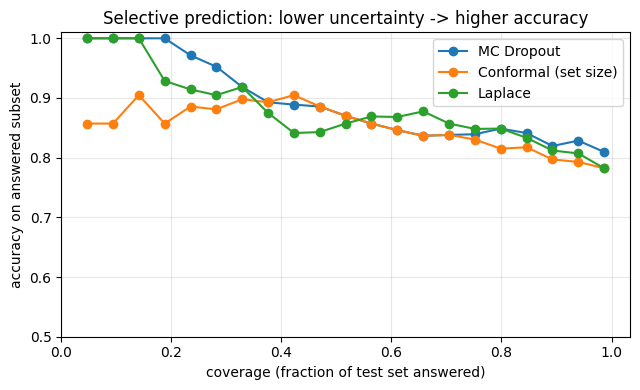

In [9]:
def selective_curve(uncertainty, predictions, y_true):
    """Return (coverage, accuracy) pairs as we abstain on the most-uncertain samples."""
    order = np.argsort(uncertainty)        # most certain first
    y_arr = np.asarray(y_true)
    n = len(order)
    coverages, accuracies = [], []
    for k in range(max(1, n // 20), n + 1, max(1, n // 20)):
        kept = order[:k]
        coverages.append(k / n)
        accuracies.append(float((predictions[kept] == y_arr[kept]).mean()))
    return np.asarray(coverages), np.asarray(accuracies)

fig, ax = plt.subplots(figsize=(6.5, 4))
for label, result in [
    ('MC Dropout', mc_result),
    ('Conformal (set size)', cp_result),
] + ([('Laplace', la_result)] if have_laplace else []):
    cov, acc = selective_curve(result.uncertainty, result.predictions, y_te)
    ax.plot(cov, acc, marker='o', linewidth=1.5, label=label)
ax.set_xlabel('coverage (fraction of test set answered)')
ax.set_ylabel('accuracy on answered subset')
ax.set_title('Selective prediction: lower uncertainty -> higher accuracy')
ax.set_ylim(0.5, 1.01)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Recap

All three estimators expose the same `predict_with_uncertainty(X)` interface and return an `UncertaintyResult` with `predictions`, `proba_mean`, `uncertainty`, optional `epistemic` / `aleatoric`, and method-specific extras under `metadata`.

| Method | Decomposes? | Calibration set? | Extra dependency | Best for |
|---|---|---|---|---|
| `MCDropoutEstimator`  | epistemic + aleatoric | no            | none           | Quick uncertainty on a model with dropout. |
| `ConformalPredictor`  | no                    | yes           | none           | Distribution-free coverage guarantees, prediction sets. |
| `LaplaceEstimator`    | epistemic + aleatoric | yes           | `laplace-torch` | Posterior-based uncertainty without retraining. |

See `docs/source/api/uncertainty.rst` for the full API reference.